In [1]:
import os
import utils.dataset_preprocessing as dprepro
import utils.image_display as imd

import glob
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
import multiprocessing as mp
import ants

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

### Dallas

In [3]:
dallas_t1_unprocessed_folder = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_unprocessed_skullstrip/"

dallas_t1_final_output_folder_bias_corrected = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_bias_corrected/"

dallas_t1_final_output_folder_resampled = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_resampled/"

dallas_t1_final_output_folder_registered = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_registered/"



dallas_t1_final_output_folder_registered_final = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_registered_final/"
os.makedirs(dallas_t1_final_output_folder_registered, exist_ok=True)
os.makedirs(dallas_t1_final_output_folder_registered_final, exist_ok=True)

Image 1 shape: (256, 256, 160)
Image 2 shape: (256, 256, 160)
Image 3 shape: (256, 256, 160)
Image 4 shape: (256, 256, 160)


<Figure size 640x480 with 0 Axes>

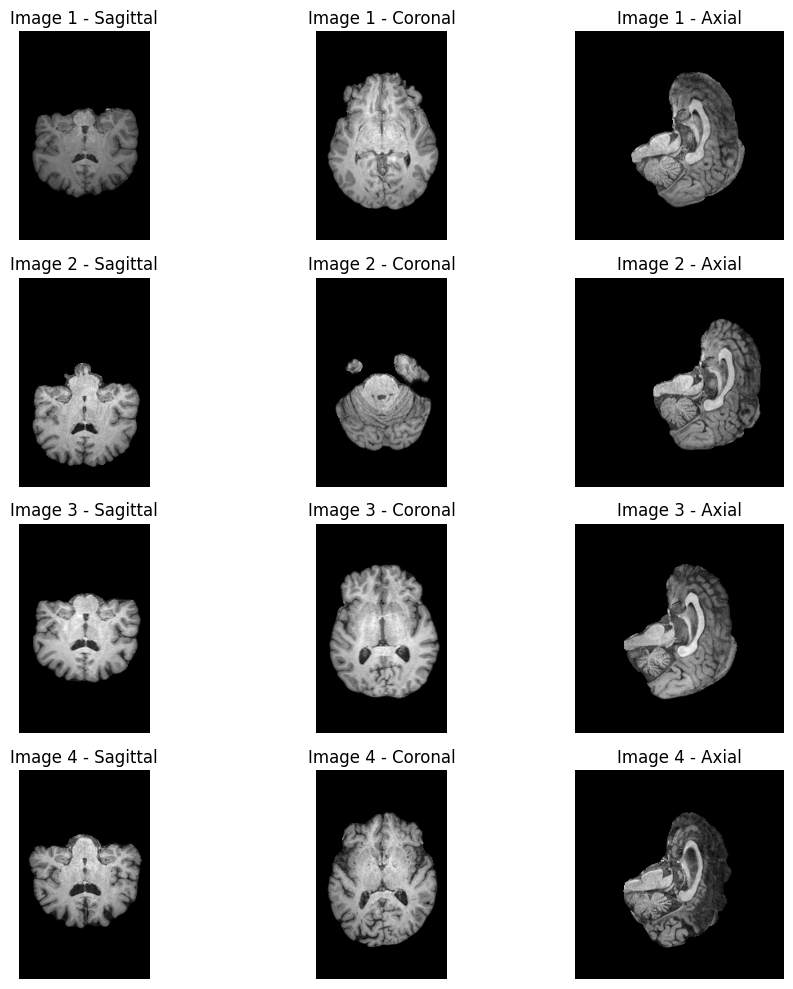

In [4]:
imd.show_first_4_nifti(dallas_t1_unprocessed_folder)

Apply bias field correction

In [6]:


def apply_bias_correction(args):
    img_file, output_folder = args
    output_filepath = os.path.join(output_folder, os.path.basename(img_file))

    if not os.path.isfile(output_filepath):
        input_image = sitk.ReadImage(img_file, sitk.sitkFloat32)

        corrector = sitk.N4BiasFieldCorrectionImageFilter()
        output_image = corrector.Execute(input_image)

        sitk.WriteImage(output_image, output_filepath)
        return f"Processed {os.path.basename(img_file)}"
    else:
        return f"Skipped {os.path.basename(img_file)}, already processed"

# Get all NIfTI files from the unprocessed folder
print("reading folder")
dallas_files = sorted(glob.glob(os.path.join(dallas_t1_unprocessed_folder, "*.nii*")))
print("finished reading folder")
tasks = [(img_file, dallas_t1_final_output_folder_registered) for img_file in dallas_files]

# Multiprocessing
with mp.Pool(processes=48) as pool:
    results = list(tqdm(pool.imap_unordered(apply_bias_correction, tasks), total=len(tasks)))


reading folder
finished reading folder


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [53:16<00:00,  3.31s/it]


Image 1 shape: (256, 256, 160)
Image 2 shape: (256, 256, 160)
Image 3 shape: (256, 256, 160)
Image 4 shape: (256, 256, 160)


<Figure size 640x480 with 0 Axes>

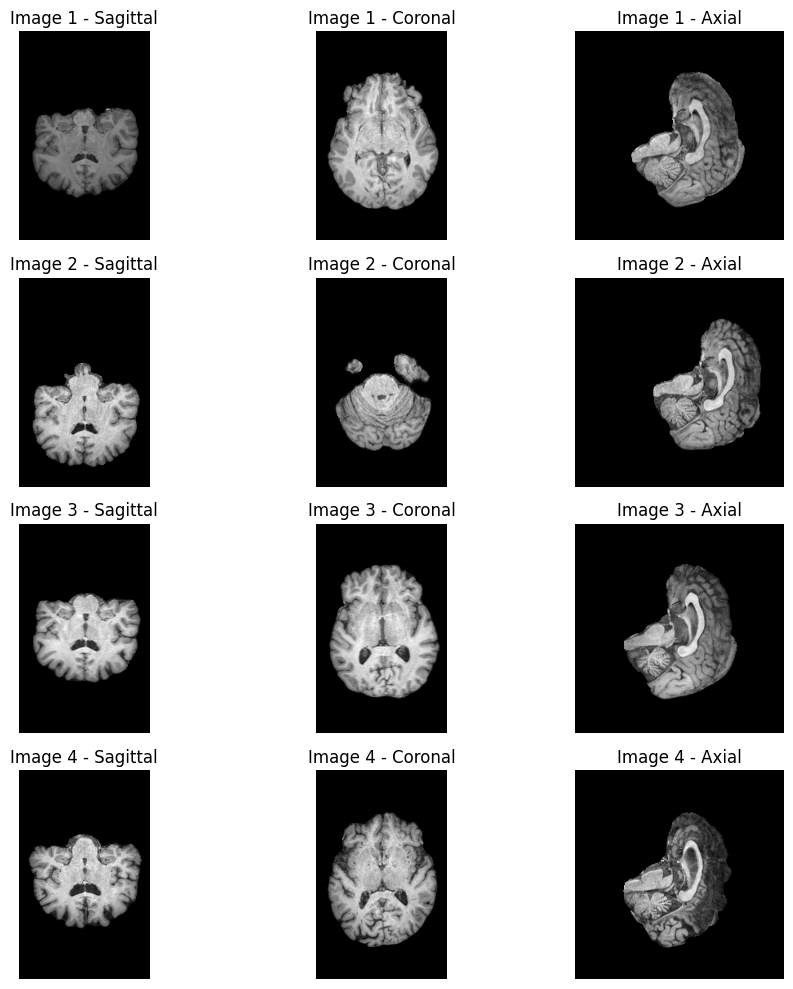

In [5]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_registered)

Resample the images to 1mm3

In [4]:
dprepro.resample_nifti_files_folder_multithreaded(
    dallas_t1_final_output_folder_bias_corrected,
    dallas_t1_final_output_folder_resampled,
    out_spacing=[1,1,1],
    max_workers=48)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [05:25<00:00,  2.97it/s]


Image 1 shape: (256, 256, 160)
Image 2 shape: (256, 256, 160)
Image 3 shape: (256, 256, 160)
Image 4 shape: (256, 256, 160)


<Figure size 640x480 with 0 Axes>

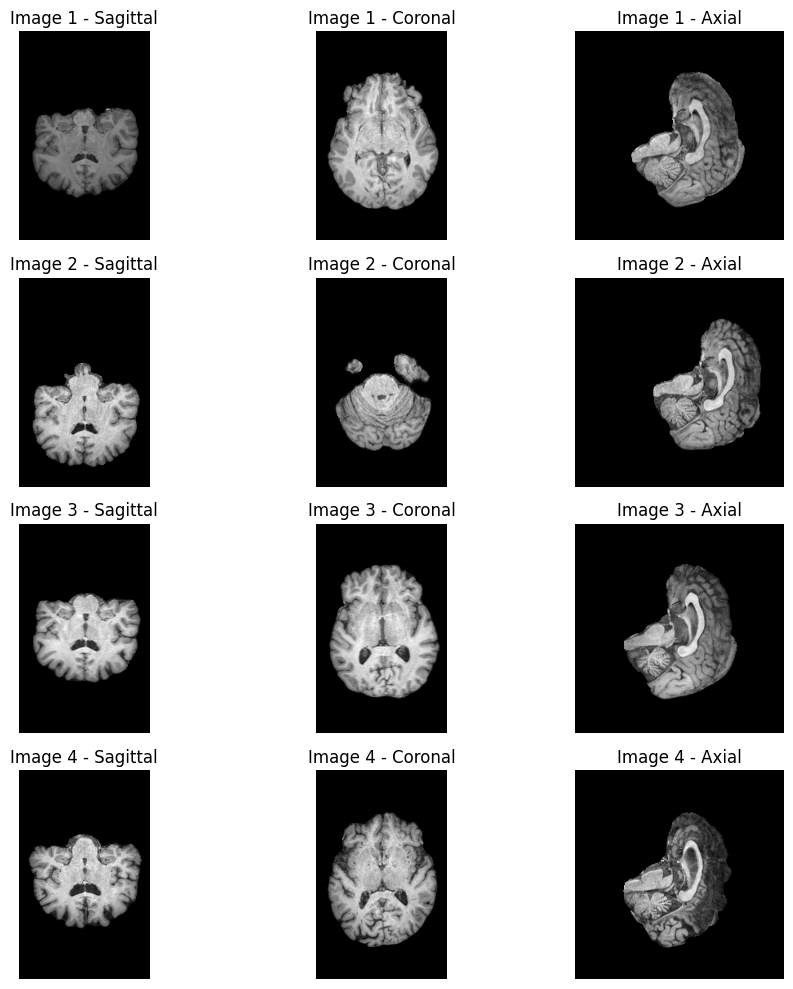

In [5]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_resampled)

In [5]:
def reorient_to_ras(image_path):
    try:
        itk_image = sitk.ReadImage(image_path)
        oriented_image = sitk.DICOMOrient(itk_image, "RAS")
        sitk.WriteImage(oriented_image, image_path)
        return None
    except Exception as e:
        return (image_path, str(e))

image_paths = glob.glob(os.path.join(dallas_t1_final_output_folder_resampled, "*.nii.gz"))

with mp.Pool(processes=min(48, mp.cpu_count())) as pool:
    results = list(tqdm(pool.imap_unordered(reorient_to_ras, image_paths), total=len(image_paths)))

errors = [r for r in results if r is not None]
print(f"Done: {len(image_paths) - len(errors)}/{len(image_paths)}")
if errors:
    print("Errors:")
    for p, msg in errors[:10]:
        print(f"- {p}: {msg}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [04:33<00:00,  3.53it/s]

Done: 967/967


Image 1 shape: (160, 256, 256)
Image 2 shape: (160, 256, 256)
Image 3 shape: (160, 256, 256)
Image 4 shape: (160, 256, 256)


<Figure size 640x480 with 0 Axes>

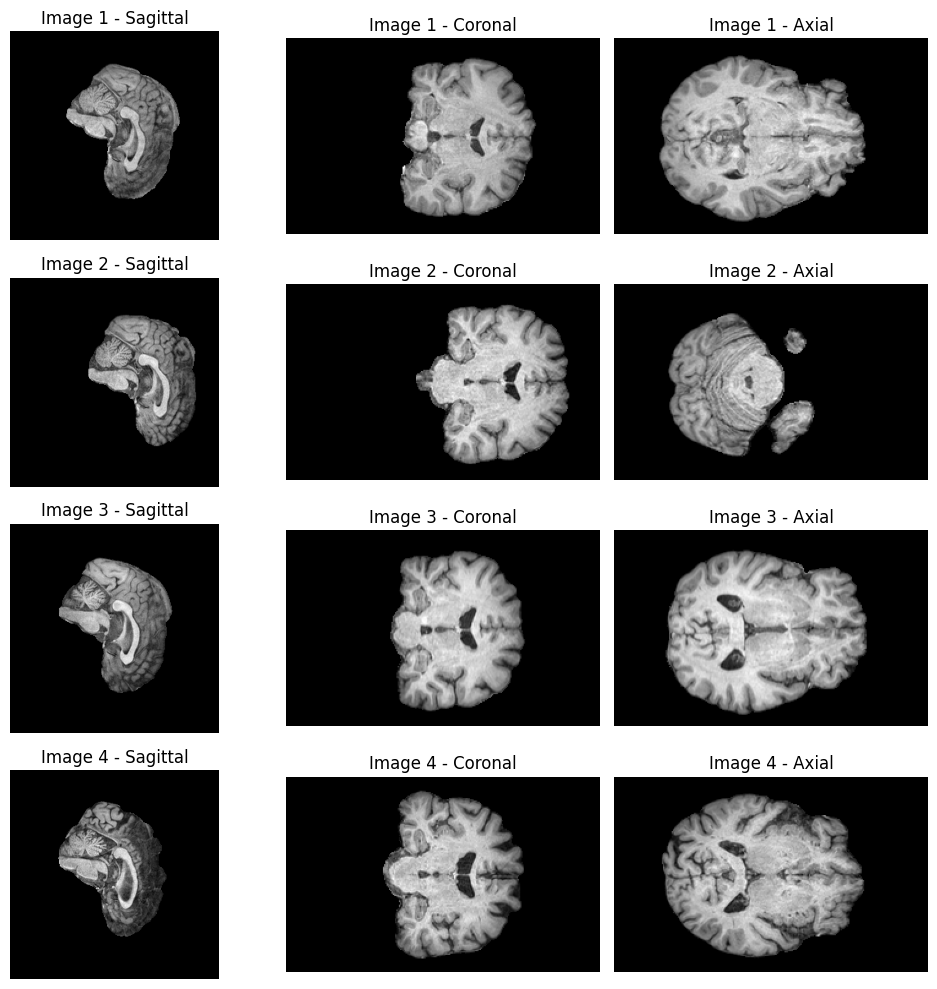

In [6]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_resampled)

In [4]:

t1_template_path = ROOT_DIR + "datasets/mni_icbm152_nlin_sym_09a/template_t1_128.nii.gz"

In [5]:
# images and masks
dprepro.register_nifti_files_folder_multithreaded(
    fixed_reference=t1_template_path,
    dataset_path=dallas_t1_final_output_folder_resampled,
    output_path = dallas_t1_final_output_folder_registered,
    register_masks=False,
    max_workers=96
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:00<00:00, 577762.39it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

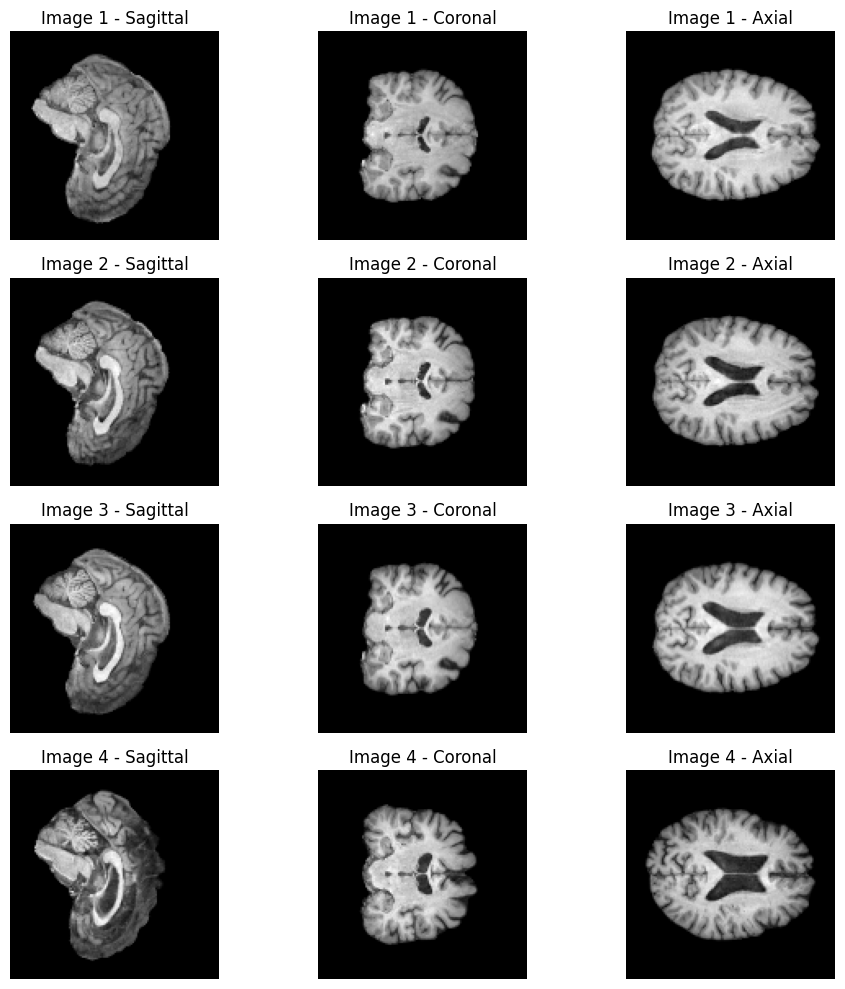

In [7]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_registered)

In [4]:
failed_t1_small_dallas = [16, 27, 62, 66, 79, 88, 162, 163, 243, 249, 260, 338, 358, 364, 470, 483, 592, 600, 708, 718, 731, 770, 797, 818, 834, 867, 887, 893, 944]

In [ ]:
# Get the list of files from the OASIS T1 dataset
dallas_files = os.listdir(dallas_t1_final_output_folder_registered)
failed_registration_final_t1_dataset_dallas_filenames = []

# Print the filenames corresponding to the failed registration indexes
print(f"Failed registration files in dallas T1 dataset ({len(failed_t1_small_dallas)} files):\n")
for idx in failed_t1_small_dallas:
    if idx < len(dallas_files):
        print(f"Index {idx}: {dallas_files[idx]}")
        failed_registration_final_t1_dataset_dallas_filenames.append(dallas_files[idx])
    else:
        print(f"Index {idx}: OUT OF RANGE (total files: {len(dallas_files)})")



Failed registration files in dallas T1 dataset (29 files):

Index 16: sub-1751_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 27: sub-164_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 62: sub-163_ses-wave3_acq-MPRAGE_run-1_T1w.nii.gz
Index 66: sub-1626_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 79: sub-1751_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 88: sub-3841_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 162: sub-162_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 163: sub-1615_ses-wave3_acq-MPRAGE_run-1_T1w.nii.gz
Index 243: sub-174_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 249: sub-1626_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 260: sub-169_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 338: sub-182_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 358: sub-1664_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 364: sub-1656_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 470: sub-1615_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz
Index 483: sub-174_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz
Index 592: sub-163_ses-wa

In [6]:
print(failed_registration_final_t1_dataset_dallas_filenames)

['sub-1751_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-164_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-163_ses-wave3_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1626_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1751_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-3841_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-162_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1615_ses-wave3_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-174_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1626_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-169_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-182_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1664_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1656_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1615_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-174_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-163_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-174_ses-wave3_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-1637_ses-wave2_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-2205_ses-wave1_acq-MPRAGE_run-1_T1w.nii.gz', 'sub-169